In [1]:
from topological_insulator import Problem

In [2]:
structure_path = "../../../../../topological_insulator/data/structures/"
structure_name = "kagome.json"

In [3]:
def _set_eigenvalues(problem:Problem, Delta_SOC, t, delta, U, occupations):
    sublattice_labels = ["A", "B", "C", "D", "E", "F"]
    cell = problem.cell_parser
    g = cell.geometry
    n_subs = len(g.delta_vectors.value)
    subs = sublattice_labels[:n_subs]
    for i, label_i in enumerate(subs):
        parser = getattr(problem.cell_parser.eigenvalues, label_i).value
        # Diagonal Values
        base = i * 8
        parser["chadi_soc"][label_i]["Delta_pp"] = Delta_SOC
        parser["interaction"][label_i]["U_p"] = U
        parser["interaction"][label_i]["n_px_up"] = occupations[2+base]
        parser["interaction"][label_i]["n_px_down"] = occupations[3+base]
        parser["interaction"][label_i]["n_py_up"] = occupations[4+base]
        parser["interaction"][label_i]["n_py_down"] = occupations[5+base]
        parser["interaction"][label_i]["n_pz_up"] = occupations[6+base]
        parser["interaction"][label_i]["n_pz_down"] = occupations[7+base]
        # Off-Diagonal Values
        for label_j in subs:
            # Hoppings
            try:
                parser["nn_hopping"][label_j]["t_pp_sigma"] = t - delta
                parser["nn_hopping"][label_j]["t_pp_pi"] = t + delta
            except:
                pass

In [4]:
location = "bulk"

In [5]:
Delta_SOC = -5
t = -1
delta = 0.832

# Spin-Liquid Occupations

x1 = [1.        , 1.        , 0.41481523, 0.41481523, 0.48031309,
       0.48031309, 0.62213433, 0.62213433, 1.        , 1.        ,
       0.41481523, 0.41481523, 0.48031309, 0.48031309, 0.62213433,
       0.62213433, 1.        , 1.        , 0.5117651 , 0.51176512,
       0.38189577, 0.38189579, 0.62120889, 0.62120888]

x3 = [1.        , 1.        , 0.41481523, 0.41481523, 0.48031309,
       0.48031309, 0.62213433, 0.62213433, 1.        , 1.        ,
       0.41481523, 0.41481523, 0.48031309, 0.48031309, 0.62213433,
       0.62213433, 1.        , 1.        , 0.5117651 , 0.51176512,
       0.38189577, 0.38189579, 0.62120889, 0.62120888]

cases = {
    0: {"U": 1, "x":x1},
    1: {"U": 3, "x":x3} 
}

In [6]:
results = {}
for n, U_dict in enumerate(cases.values()):
    U = U_dict["U"]
    x = U_dict["x"]
    print("")
    print(f"Running case for: delta/t_1 = {delta/t}, and U/t = {U/t}")
    problem = Problem(structure_path=structure_path, structure_name=structure_name)
    _set_eigenvalues(problem, Delta_SOC, t, delta, U, x)
    problem.setup(
        N_r = 10,
        N_k = 400,
        location = location,
        BZ = "reduced"
    )
    problem.run(
        H_type="reciprocal"
    )
    results[n] = problem


Running case for: delta/t_1 = -0.832, and U/t = -1.0
Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!

Running case for: delta/t_1 = -0.832, and U/t = -3.0
Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!


In [17]:
j_3_2 = [i for i in range(12, 23)]
bands = [22, 23]

## Case 0

Calculating Z2 Invariant...
k=[0.0, 0.0]: delta = -1.0
k=[ 1.57079633 -0.90689968]: delta = -1.0
k=[0.         1.81379936]: delta = 1.0
k=[1.57079633 0.90689968]: delta = 1.0
Z2 Invariant - Done!
Z2 Invariant: 0
-0.18631975736283302


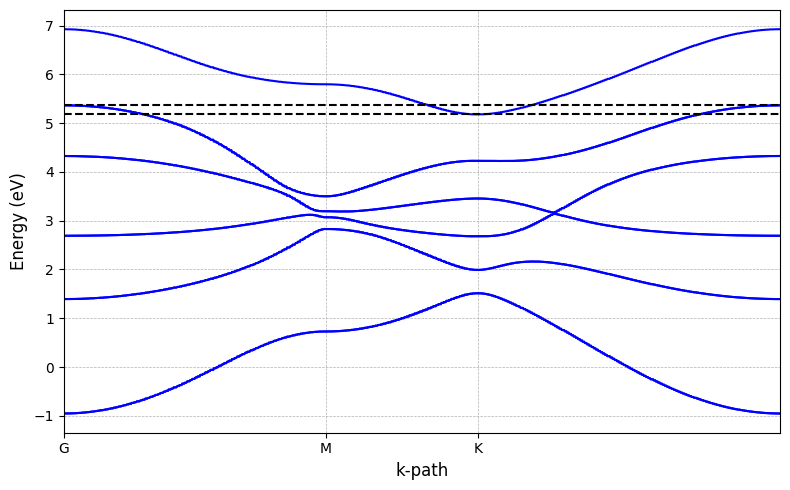

In [18]:
g = results[0].geometry
tb_bulk = results[0].hamiltonian[location]["tight_binding"]
invariants = results[0].hamiltonian[location]["topological_invariants"]

Z2 = invariants.Z2_invariant(bands, print_deltas=True)
print(f"Z2 Invariant: {Z2}")
dE, E_0, E_1 = invariants.get_band_gap(23, 21, only_dE=False)
print(dE)
tb_bulk.plot_band_structure(g, j_3_2, energies=[E_0, E_1])

## Case 1

Calculating Z2 Invariant...
k=[0.0, 0.0]: delta = 1.0
k=[ 1.57079633 -0.90689968]: delta = -1.0
k=[0.         1.81379936]: delta = -1.0
k=[1.57079633 0.90689968]: delta = 1.0
Z2 Invariant - Done!
Z2 Invariant: 0
-0.22941062670613288


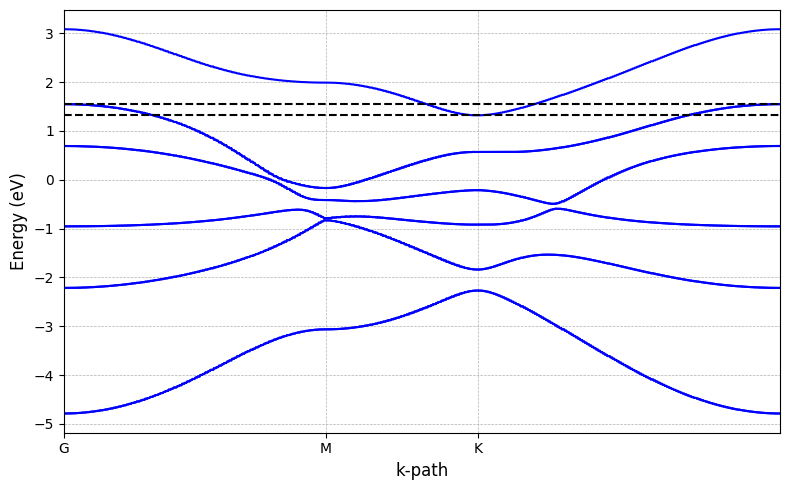

In [19]:
g = results[1].geometry
tb_bulk = results[1].hamiltonian[location]["tight_binding"]
invariants = results[1].hamiltonian[location]["topological_invariants"]
Z2 = invariants.Z2_invariant(bands, print_deltas=True)
print(f"Z2 Invariant: {Z2}")
dE, E_0, E_1 = invariants.get_band_gap(23, 21, only_dE=False)
print(dE)
tb_bulk.plot_band_structure(g, j_3_2,  energies=[E_0, E_1])